In [6]:
from glob import glob

import uproot
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

In [7]:
def get_hist(file, histname):
    hist = file[histname]

    # Данные гистограммы (значения и ошибки)
    values = hist.values()  # 3D-массив значений
    errors = hist.errors()   # 3D-массив ошибок (опционально)

    # Границы и центры бинов по осям
    x_edges = hist.axis(0).edges()  # Границы бинов по X
    y_edges = hist.axis(1).edges()  # Границы бинов по Y
    z_edges = hist.axis(2).edges()  # Границы бинов по Z

    x_centers = (x_edges[:-1] + x_edges[1:]) / 2  # Центры бинов по X
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2  # Центры бинов по Y
    z_centers = (z_edges[:-1] + z_edges[1:]) / 2  # Центры бинов по Z

    # Ширина бинов
    x_widths = np.diff(x_edges)  # Ширина бинов по X
    y_widths = np.diff(y_edges)  # Ширина бинов по Y
    z_widths = np.diff(z_edges)  # Ширина бинов по Z

    # Создаём сетку координат и номеров бинов
    xx, yy, zz = np.meshgrid(
        x_centers, y_centers, z_centers,
        indexing="ij"  # важно для соответствия ROOT-бинингу
    )

    # Номера бинов (начинаются с 1, как в ROOT)
    bin_x, bin_y, bin_z = np.meshgrid(
        np.arange(1, len(x_centers) + 1),
        np.arange(1, len(y_centers) + 1),
        np.arange(1, len(z_centers) + 1),
        indexing="ij"
    )

    # Ширина бинов (расширяем до 3D)
    xx_width, yy_width, zz_width = np.meshgrid(
        x_widths, y_widths, z_widths,
        indexing="ij"
    )

    # Собираем всё в DataFrame
    df = pd.DataFrame({
        # Координаты центров бинов
        "x": xx.ravel(),
        "y": yy.ravel(),
        "z": zz.ravel(),

        # Номера бинов (как в ROOT, от 1 до Nbins)
        "ix": bin_x.ravel(),
        "iy": bin_y.ravel(),
        "iz": bin_z.ravel(),

        # Ширина бинов
        "dx": xx_width.ravel(),
        "dy": yy_width.ravel(),
        "dz": zz_width.ravel(),

        # Значения и ошибки
        "e": values.ravel(),
        "e2": errors.ravel()  # опционально
    })


    # Проверяем, что для каждого z есть -z
    assert all(-z in z_centers for z in z_centers if z > 0), "Гистограмма не симметрична по Z!"

    df['m'] = df['dx']*df['dy']*df['dz']
    df['d'] = df['e'] / df['m']
    return df

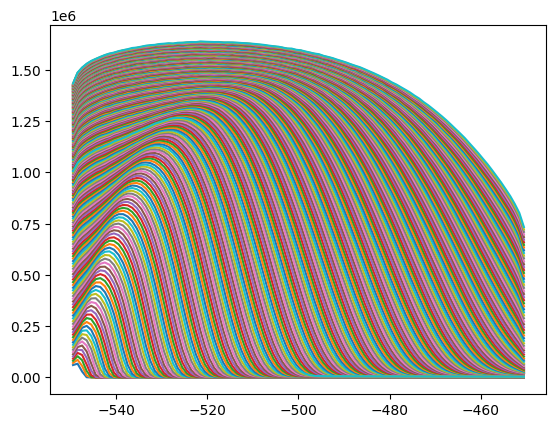

In [11]:
for f in sorted(glob("data/*-MeV/*.root")):
    file = uproot.open(f)
    df = get_hist(file, "vdd")
    pdd = [df[df['iz'] == iz]['d'].sum() for iz in df['iz'].unique()][::-1]
    plt.plot(df['z'].unique(), pdd, label=f.split('/')[1])
# plt.legend()
plt.show()
plt.close()

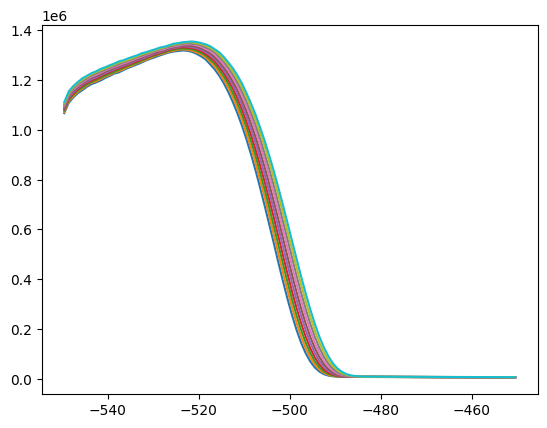

In [10]:
for f in sorted(glob("data/11*-MeV/*.root")):
    file = uproot.open(f)
    df = get_hist(file, "vdd")
    pdd = [df[df['iz'] == iz]['d'].sum() for iz in df['iz'].unique()][::-1]
    plt.plot(df['z'].unique(), pdd, label=f.split('/')[1])
# plt.legend()
plt.show()
plt.close()